In [1]:
# Week 1: Install libraries
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn -q

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [2]:
# Week 1: Upload FD004 files
from google.colab import files
print("Please upload train_FD004.txt and test_FD004.txt")
uploaded = files.upload()

Please upload train_FD004.txt and test_FD004.txt


Saving train_FD004.txt to train_FD004.txt
Saving test_FD004.txt to test_FD004.txt


In [10]:
# Week 2: Load FD002 data
train = pd.read_csv('train_FD004.txt', sep=" ", header=None)
test = pd.read_csv('test_FD004.txt', sep=" ", header=None)

# Remove empty columns
train = train.dropna(axis=1, how='all')
test = test.dropna(axis=1, how='all')

In [11]:
# Week 2: Assign column names
cols = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]
train.columns = cols
test.columns = cols

print("TRAIN DATASET INFO")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Number of engines in train: {train['engine_id'].nunique()}")
print(f"Number of engines in test: {test['engine_id'].nunique()}")
print(f"Total cycles in train: {train['cycle'].sum()}")
print(f"Total cycles in test: {test['cycle'].sum()}")
print("\nFirst 5 rows of training data:")
print(train.head())
print("\nMissing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

TRAIN DATASET INFO
Train Shape: (61249, 26)
Test Shape: (41214, 26)
Number of engines in train: 249
Number of engines in test: 248
Total cycles in train: 8226440
Total cycles in test: 4481573

First 5 rows of training data:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       42.0049        0.8400         100.0    445.00   
1          1      2       20.0020        0.7002         100.0    491.19   
2          1      3       42.0038        0.8409         100.0    445.00   
3          1      4       42.0000        0.8400         100.0    445.00   
4          1      5       25.0063        0.6207          60.0    462.54   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    549.68   1343.43   1112.93      3.91  ...     129.78    2387.99   
1    606.07   1477.61   1237.50      9.35  ...     312.59    2387.73   
2    548.95   1343.12   1117.05      3.91  ...     129.62    2387.97   
3    548.70   1341.24   1118.03      

In [12]:
# Week 3: Remove low variance sensors (variance < 0.0001)
sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"\nTotal sensors initially: {len(sensor_cols)}")

variances = train[sensor_cols].var()
low_var_cols = variances[variances < 0.0001].index.tolist()
train = train.drop(columns=low_var_cols)
test = test.drop(columns=low_var_cols)
print(f"Removed {len(low_var_cols)} low variance sensors")

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Sensors after low variance removal: {len(sensor_cols)}")


Total sensors initially: 21
Removed 1 low variance sensors
Sensors after low variance removal: 20


In [13]:
# Week 3: Remove highly correlated sensors (>0.95)
corr_matrix = train[sensor_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]

train = train.drop(columns=high_corr_cols)
test = test.drop(columns=high_corr_cols)
print(f"Removed {len(high_corr_cols)} highly correlated sensors")

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Final sensors selected: {len(sensor_cols)}")
print(f"Sensors: {sensor_cols}")

Removed 15 highly correlated sensors
Final sensors selected: 5
Sensors: ['sensor_1', 'sensor_2', 'sensor_8', 'sensor_13', 'sensor_14']


In [14]:
# Week 4: Normalization (Z-score)
scaler = StandardScaler()
train[sensor_cols] = scaler.fit_transform(train[sensor_cols])
test[sensor_cols] = scaler.transform(test[sensor_cols])

print("\nNormalization complete!")
print(f"Train mean after normalization: {train[sensor_cols].mean().mean():.6f}")
print(f"Train std after normalization: {train[sensor_cols].std().mean():.6f}")


Normalization complete!
Train mean after normalization: -0.000000
Train std after normalization: 1.000008


In [15]:
# Week 4: Window segmentation
window_size = 30
anomaly_ratio = 0.20

def create_windows(data, window_size):
    X = []
    engine_ids = []
    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        for i in range(len(engine_data) - window_size):
            window = engine_data.iloc[i:i+window_size][sensor_cols].values
            X.append(window)
            engine_ids.append(engine)
    return np.array(X), engine_ids

def create_anomaly_labels(data, window_size, anomaly_ratio=0.20):
    labels = []
    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        max_cycle = engine_data['cycle'].max()
        anomaly_start_cycle = max_cycle - int(max_cycle * anomaly_ratio)
        for i in range(len(engine_data) - window_size):
            window_end_cycle = engine_data.iloc[i + window_size - 1]['cycle']
            if window_end_cycle >= anomaly_start_cycle:
                labels.append(1)
            else:
                labels.append(0)
    return np.array(labels)

In [16]:
# Week 4: Create windows and labels
print("\nCreating windows...")
X_train, train_engine_ids = create_windows(train, window_size)
X_test, test_engine_ids = create_windows(test, window_size)

y_train = create_anomaly_labels(train, window_size, anomaly_ratio)
y_test = create_anomaly_labels(test, window_size, anomaly_ratio)

print(f"\nWindows created successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nNormal samples in train: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"Anomaly samples in train: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

# Extract only normal samples for training
X_train_normal = X_train[y_train == 0]
print(f"\nTraining on normal samples only: {X_train_normal.shape}")


Creating windows...

Windows created successfully!
X_train shape: (53779, 30, 5)
X_test shape: (33844, 30, 5)
y_train shape: (53779,)
y_test shape: (33844,)

Normal samples in train: 41633 (77.41%)
Anomaly samples in train: 12146 (22.59%)

Training on normal samples only: (41633, 30, 5)


Flattened input dimension: 150

Dense Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        19,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,254 (215.84 KB)

 Trainable params: 55,254 (215.84 KB)

 Non-trainable params: 0 (0.00 B)


Training Dense Autoencoder...
Epoch 1/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5617 - val_loss: 0.1268
Epoch 2/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1003 - val_loss: 0.0519
Epoch 3/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0424 - val_loss: 0.0283
Epoch 4/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0266 - val_loss: 0.0225
Epoch 5/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0217 - val_loss: 0.0210
Epoch 6/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0206 - val_loss: 0.0208
Epoch 7/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0204 - val_loss: 0.0205
Epoch 8/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0202 - val_loss: 0.0205
Epoch 9/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0202 - val_loss: 0.0212
Epoch 10/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0201 - val_loss: 0.0209


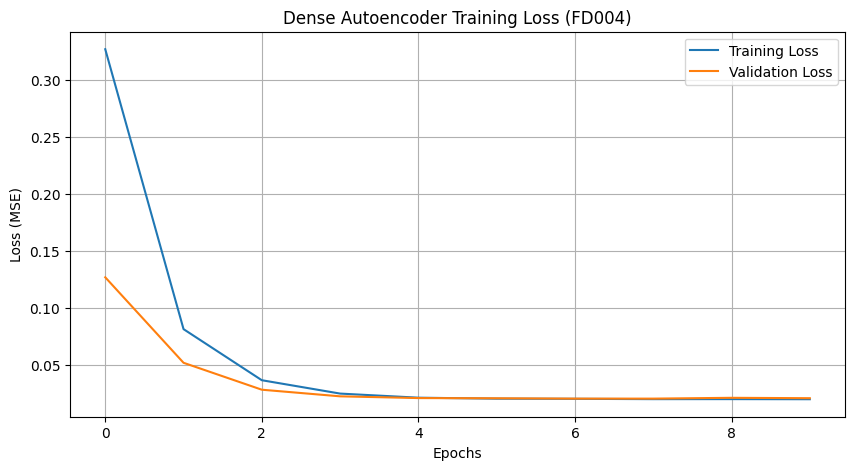

In [17]:
# Week 5: Dense Autoencoder
X_train_flat = X_train_normal.reshape(X_train_normal.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
print(f"Flattened input dimension: {input_dim}")

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

dense_ae = Model(input_layer, decoded)
dense_ae.compile(optimizer='adam', loss='mse')

print("\nDense Autoencoder Summary:")
dense_ae.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Dense Autoencoder...")
history_dense = dense_ae.fit(
    X_train_flat, X_train_flat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_dense.history['loss'], label='Training Loss')
plt.plot(history_dense.history['val_loss'], label='Validation Loss')
plt.title('Dense Autoencoder Training Loss (FD004)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Timesteps: 30, Features: 5

LSTM Autoencoder Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,269 (200.27 KB)

 Trainable params: 51,269 (200.27 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Autoencoder...
Epoch 1/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - loss: 0.9176 - val_loss: 0.8417
Epoch 2/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - loss: 0.7735 - val_loss: 0.7259
Epoch 3/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - loss: 0.6874 - val_loss: 0.6828
Epoch 4/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 0.6469 - val_loss: 0.6511
Epoch 5/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - loss: 0.6268 - val_loss: 0.6353
Epoch 6/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - loss: 0.6072 - val_loss: 0.6193
Epoch 7/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 0.5866 - val_loss: 0.6086
Epoch 8/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - loss: 0.5717 - val_loss: 0.5817
Epoch 9/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - loss: 0.5586 - val_loss: 0.5656
Epoch 10/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - loss: 0.5398 - val_loss: 0.6066
Epoch 11/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - loss: 0.5379 - val_loss: 0.5199


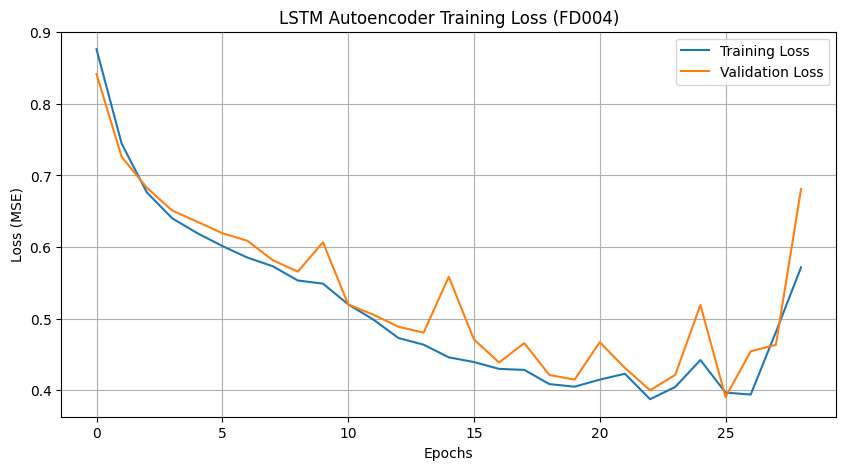

In [18]:
# Week 6: LSTM Autoencoder
timesteps = X_train.shape[1]
features = X_train.shape[2]
print(f"Timesteps: {timesteps}, Features: {features}")

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='tanh')(input_layer)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_ae = Model(input_layer, decoded)
lstm_ae.compile(optimizer='adam', loss='mse')

print("\nLSTM Autoencoder Summary:")
lstm_ae.summary()

print("\nTraining LSTM Autoencoder...")
history_lstm = lstm_ae.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Training Loss (FD004)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


CNN-LSTM Autoencoder Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        16,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 5)          │           255 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,567 (146.75 KB)

 Trainable params: 37,567 (146.75 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM Autoencoder...
Epoch 1/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - loss: 0.9326 - val_loss: 0.8749
Epoch 2/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - loss: 0.8270 - val_loss: 0.7693
Epoch 3/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - loss: 0.7345 - val_loss: 0.7211
Epoch 4/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.6901 - val_loss: 0.7018
Epoch 5/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - loss: 0.6668 - val_loss: 0.6690
Epoch 6/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - loss: 0.6310 - val_loss: 0.6354
Epoch 7/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.6049 - val_loss: 0.5995
Epoch 8/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 0.5891 - val_loss: 0.5773
Epoch 9/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - loss: 0.5381 - val_loss: 0.5399
Epoch 10/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - loss: 0.5085 - val_loss: 0.5211
Epoch 11/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - loss: 0.4875 - val_loss: 0.4

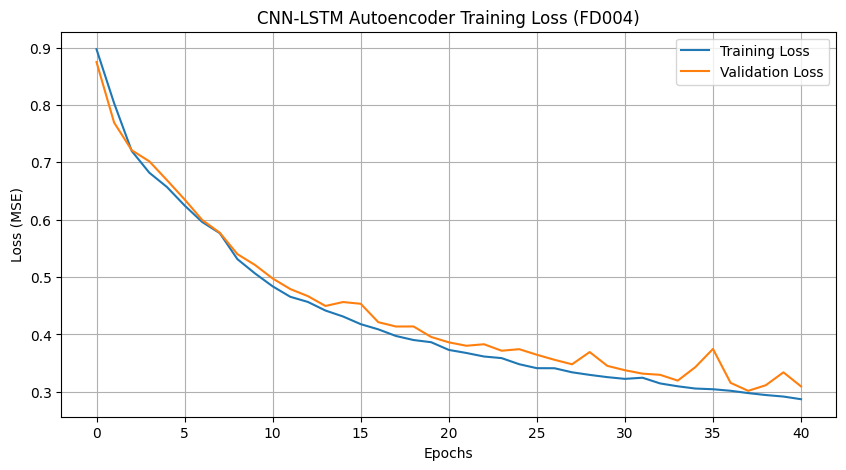

In [19]:
# Week 7: CNN-LSTM Autoencoder
input_layer = Input(shape=(timesteps, features))
x = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(50, return_sequences=False)(x)
x = RepeatVector(timesteps)(x)
x = LSTM(50, return_sequences=True)(x)
decoded = TimeDistributed(Dense(features))(x)

cnn_lstm = Model(input_layer, decoded)
cnn_lstm.compile(optimizer='adam', loss='mse')

print("\nCNN-LSTM Autoencoder Summary:")
cnn_lstm.summary()

print("\nTraining CNN-LSTM Autoencoder...")
history_cnn = cnn_lstm.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN-LSTM Autoencoder Training Loss (FD004)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Week 8: Threshold selection
def compute_reconstruction_error(model, X, flatten=False):
    if flatten:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=1)
    else:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=(1, 2))
    return mse

# Validation split
val_size = int(len(X_train_normal) * 0.1)
X_val = X_train_normal[:val_size]
X_train_norm = X_train_normal[val_size:]

# Dense AE
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_train_norm_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)

errors_dense_val = compute_reconstruction_error(dense_ae, X_val_flat, flatten=True)
errors_lstm_val = compute_reconstruction_error(lstm_ae, X_val)
errors_cnn_val = compute_reconstruction_error(cnn_lstm, X_val)

errors_train_dense = compute_reconstruction_error(dense_ae, X_train_norm_flat, flatten=True)
errors_train_lstm = compute_reconstruction_error(lstm_ae, X_train_norm)
errors_train_cnn = compute_reconstruction_error(cnn_lstm, X_train_norm)

thresh_dense_p95 = np.percentile(errors_train_dense, 95)
thresh_lstm_p95 = np.percentile(errors_train_lstm, 95)
thresh_cnn_p95 = np.percentile(errors_train_cnn, 95)

def find_threshold_by_fpr(errors_val, target_fpr=0.05):
    sorted_errors = np.sort(errors_val)
    index = int(len(sorted_errors) * (1 - target_fpr))
    index = min(index, len(sorted_errors) - 1)
    return sorted_errors[index]

thresh_dense_val = find_threshold_by_fpr(errors_dense_val, target_fpr=0.05)
thresh_lstm_val = find_threshold_by_fpr(errors_lstm_val, target_fpr=0.05)
thresh_cnn_val = find_threshold_by_fpr(errors_cnn_val, target_fpr=0.05)

print("\nThreshold values (FD004):")
print(f"Dense AE  - P95: {thresh_dense_p95:.4f}, Validation (FPR≤5%): {thresh_dense_val:.4f}")
print(f"LSTM AE   - P95: {thresh_lstm_p95:.4f}, Validation (FPR≤5%): {thresh_lstm_val:.4f}")
print(f"CNN-LSTM  - P95: {thresh_cnn_p95:.4f}, Validation (FPR≤5%): {thresh_cnn_val:.4f}")


Threshold values (FD004):
Dense AE  - P95: 0.0420, Validation (FPR≤5%): 0.0401
LSTM AE   - P95: 0.5782, Validation (FPR≤5%): 0.5689
CNN-LSTM  - P95: 0.4314, Validation (FPR≤5%): 0.4141


In [21]:
# Week 9: Model evaluation
errors_test_dense = compute_reconstruction_error(dense_ae, X_test_flat, flatten=True)
errors_test_lstm = compute_reconstruction_error(lstm_ae, X_test)
errors_test_cnn = compute_reconstruction_error(cnn_lstm, X_test)

# Inference time
start_time = time.time()
_ = dense_ae.predict(X_test_flat[:100], verbose=0)
inf_time_dense = (time.time() - start_time) / 100
start_time = time.time()
_ = lstm_ae.predict(X_test[:100], verbose=0)
inf_time_lstm = (time.time() - start_time) / 100
start_time = time.time()
_ = cnn_lstm.predict(X_test[:100], verbose=0)
inf_time_cnn = (time.time() - start_time) / 100

def evaluate_model(y_true, errors, threshold, model_name, threshold_type, inference_time):
    y_pred = (errors > threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, errors)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {
        'Model': model_name,
        'Threshold Type': threshold_type,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'False Alarm Rate': round(far, 4),
        'Inference Time (s)': round(inference_time, 6)
    }

results = []
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_p95, 'Dense AE', 'Percentile (95th)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_p95, 'LSTM AE', 'Percentile (95th)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_p95, 'CNN-LSTM', 'Percentile (95th)', inf_time_cnn))
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_val, 'Dense AE', 'Validation (FPR≤5%)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_val, 'LSTM AE', 'Validation (FPR≤5%)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_val, 'CNN-LSTM', 'Validation (FPR≤5%)', inf_time_cnn))

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL RESULTS - FD004 ANOMALY DETECTION PERFORMANCE")
print("="*80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('anomaly_detection_results_FD004.csv', index=False)
print("\nResults saved to 'anomaly_detection_results_FD004.csv'")


FINAL RESULTS - FD004 ANOMALY DETECTION PERFORMANCE
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.2831  0.0662    0.1073   0.5567            0.0527            0.001265
 LSTM AE   Percentile (95th)     0.2597  0.0510    0.0853   0.5255            0.0457            0.001894
CNN-LSTM   Percentile (95th)     0.2653  0.0633    0.1023   0.5200            0.0552            0.001639
Dense AE Validation (FPR≤5%)     0.2795  0.0761    0.1196   0.5567            0.0617            0.001265
 LSTM AE Validation (FPR≤5%)     0.2644  0.0574    0.0943   0.5255            0.0503            0.001894
CNN-LSTM Validation (FPR≤5%)     0.2648  0.0788    0.1214   0.5200            0.0688            0.001639

Results saved to 'anomaly_detection_results_FD004.csv'


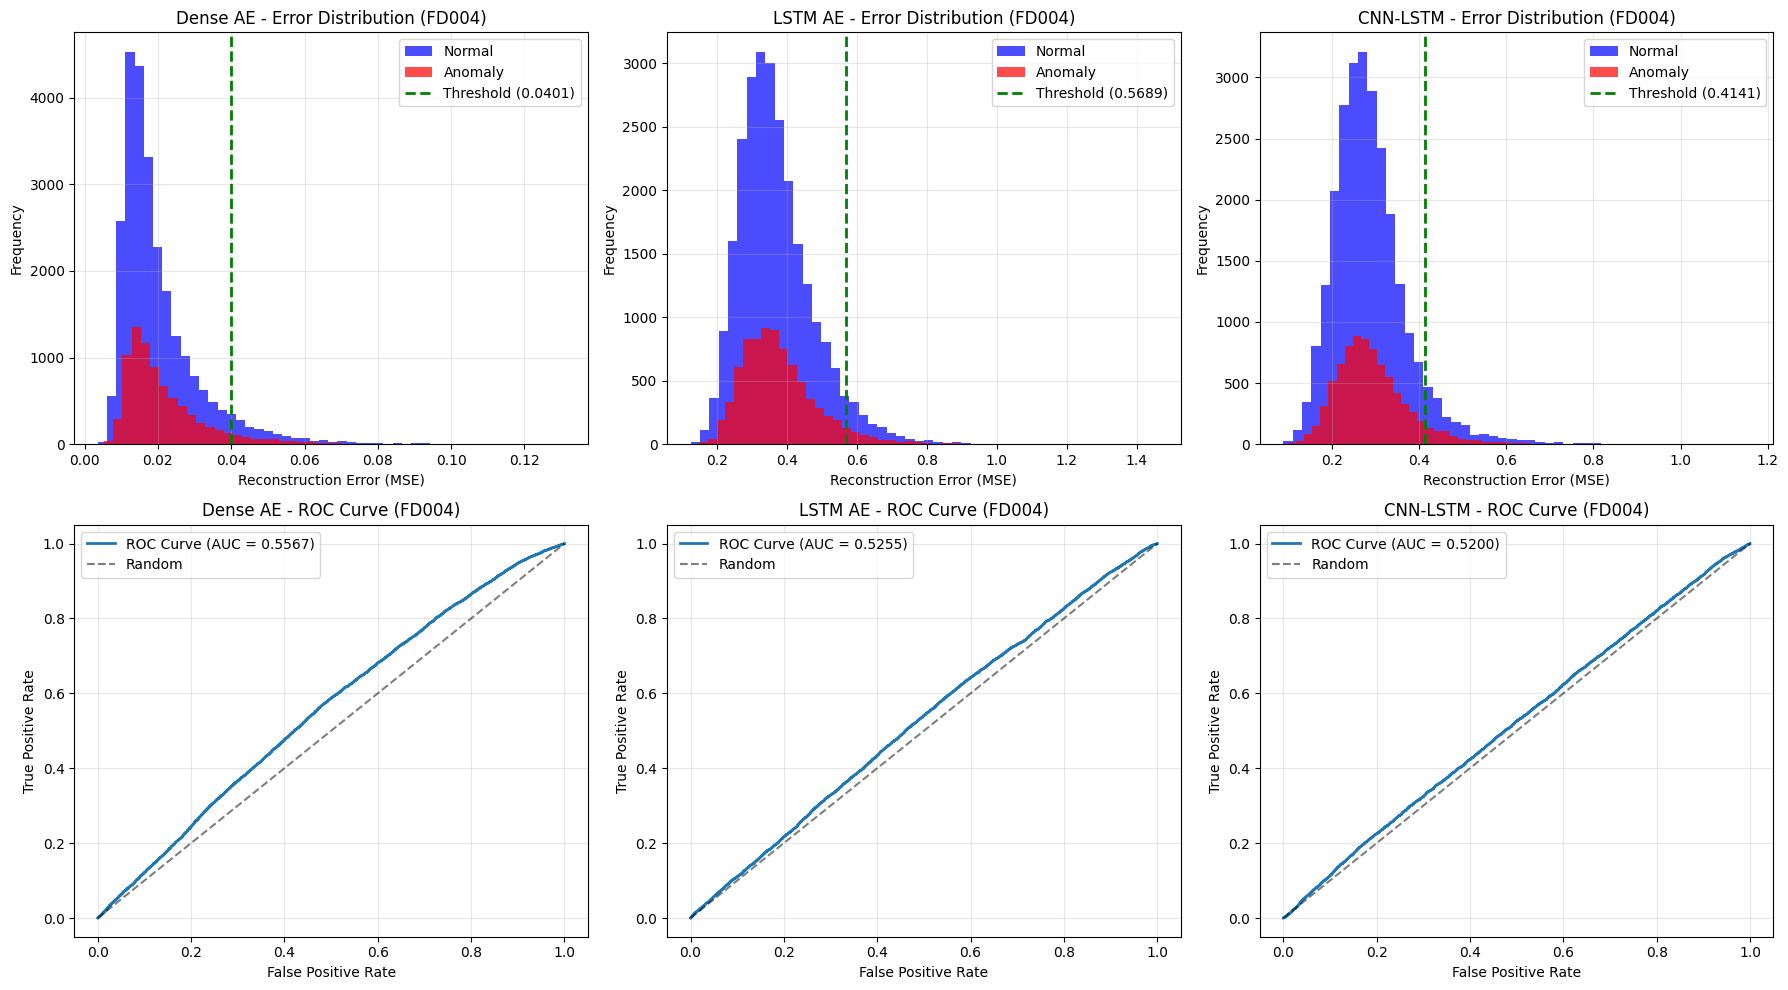

Figure saved: fd004_error_roc.png


In [22]:
# Week 9: Visualizations
models = ['Dense AE', 'LSTM AE', 'CNN-LSTM']
errors_list = [errors_test_dense, errors_test_lstm, errors_test_cnn]
thresholds_val = [thresh_dense_val, thresh_lstm_val, thresh_cnn_val]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: Error distributions
for i, (ax, name, errors, thresh) in enumerate(zip(axes[0], models, errors_list, thresholds_val)):
    ax.hist(errors[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue')
    ax.hist(errors[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red')
    ax.axvline(thresh, color='green', linestyle='--', linewidth=2, label=f'Threshold ({thresh:.4f})')
    ax.set_title(f'{name} - Error Distribution (FD004)')
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Row 1: ROC Curves
for i, (ax, name, errors) in enumerate(zip(axes[1], models, errors_list)):
    fpr, tpr, _ = roc_curve(y_test, errors)
    auc = roc_auc_score(y_test, errors)
    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_title(f'{name} - ROC Curve (FD004)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fd004_error_roc.png', dpi=300)
plt.show()
print("Figure saved: fd004_error_roc.png")

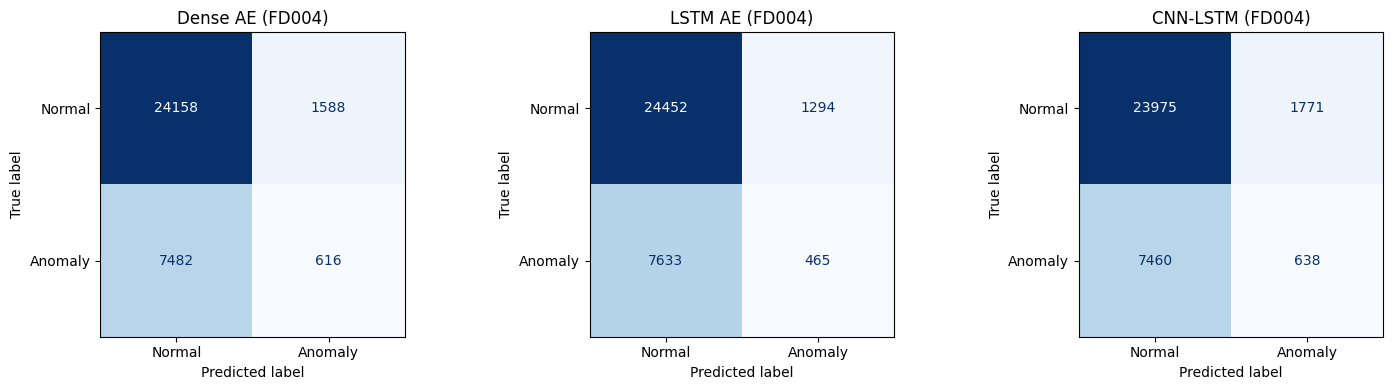

Figure saved: fd004_confusion_matrices.png


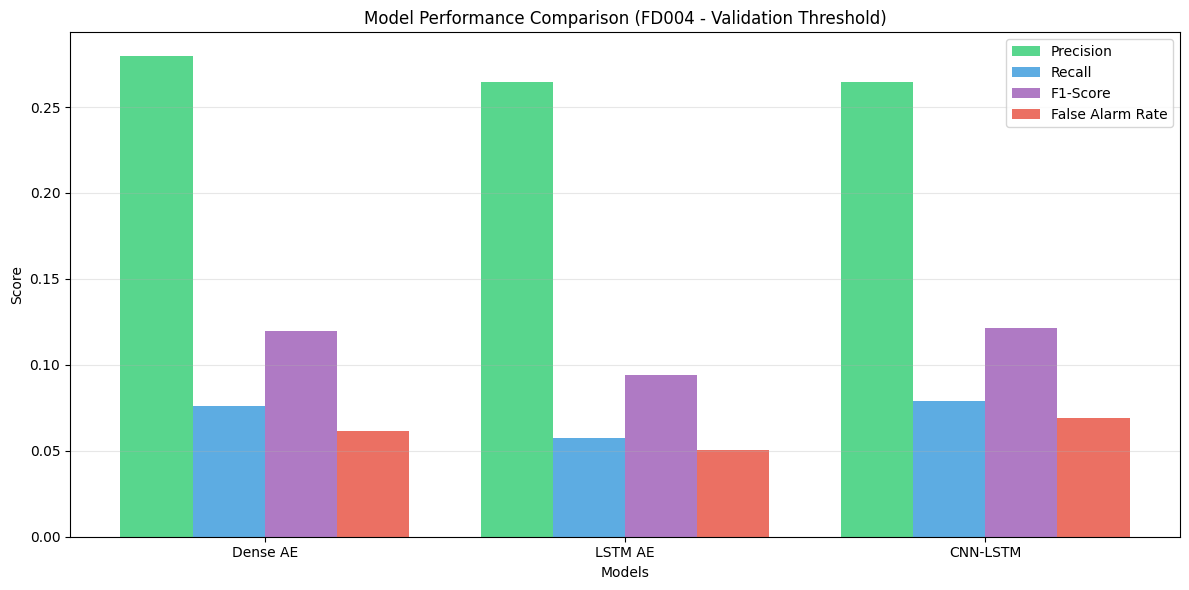

Figure saved: fd004_bar_chart.png


In [23]:
# Week 9: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, errors, thresh in zip(axes, models, errors_list, thresholds_val):
    y_pred = (errors > thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (FD004)')
plt.tight_layout()
plt.savefig('fd004_confusion_matrices.png', dpi=300)
plt.show()
print("Figure saved: fd004_confusion_matrices.png")

# Bar chart
val_results = results_df[results_df['Threshold Type'] == 'Validation (FPR≤5%)']
x = np.arange(len(val_results))
width = 0.2
metrics = ['Precision', 'Recall', 'F1-Score', 'False Alarm Rate']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = val_results[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=color, alpha=0.8)
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (FD004 - Validation Threshold)')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(val_results['Model'].values)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fd004_bar_chart.png', dpi=300)
plt.show()
print("Figure saved: fd004_bar_chart.png")

In [24]:
# Week 10: Output collection for Chapter 4 (FD004)
print("="*60)
print("📌 FD004 DATASET STATISTICS")
print("="*60)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Engines in train: {train['engine_id'].nunique()}")
print(f"Engines in test: {test['engine_id'].nunique()}")
print(f"Final sensors selected: {len(sensor_cols)}")

print("\n" + "="*60)
print("📌 CLASS DISTRIBUTION")
print("="*60)
print(f"TRAIN: Normal: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%), "
      f"Anomaly: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"TEST:  Normal: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%), "
      f"Anomaly: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

print("\n" + "="*60)
print("📌 THRESHOLD VALUES")
print("="*60)
print(f"Dense AE  - P95: {thresh_dense_p95:.6f}, Val: {thresh_dense_val:.6f}")
print(f"LSTM AE   - P95: {thresh_lstm_p95:.6f}, Val: {thresh_lstm_val:.6f}")
print(f"CNN-LSTM  - P95: {thresh_cnn_p95:.6f}, Val: {thresh_cnn_val:.6f}")

print("\n" + "="*60)
print("📌 FINAL RESULTS TABLE (FD004)")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("✅ FD004 implementation complete! All results saved.")
print("="*60)

📌 FD004 DATASET STATISTICS
Train shape: (61249, 10)
Test shape: (41214, 10)
Engines in train: 249
Engines in test: 248
Final sensors selected: 5

📌 CLASS DISTRIBUTION
TRAIN: Normal: 41633 (77.41%), Anomaly: 12146 (22.59%)
TEST:  Normal: 25746 (76.07%), Anomaly: 8098 (23.93%)

📌 THRESHOLD VALUES
Dense AE  - P95: 0.041978, Val: 0.040075
LSTM AE   - P95: 0.578168, Val: 0.568880
CNN-LSTM  - P95: 0.431361, Val: 0.414114

📌 FINAL RESULTS TABLE (FD004)
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.2831  0.0662    0.1073   0.5567            0.0527            0.001265
 LSTM AE   Percentile (95th)     0.2597  0.0510    0.0853   0.5255            0.0457            0.001894
CNN-LSTM   Percentile (95th)     0.2653  0.0633    0.1023   0.5200            0.0552            0.001639
Dense AE Validation (FPR≤5%)     0.2795  0.0761    0.1196   0.5567            0.0617            0.001265
 LSTM AE Validation (FPR≤